# Part A — Supervised model + metrics (20 marks)

Q1. SVM on Breast Cancer dataset + metrics + confusion matrix plot (20 marks)

Use sklearn’s breast cancer dataset.

1. Load the dataset (X, y). Split into train/test (80/20, stratified, fixed random_state).
2. Build a pipeline with:

* StandardScaler
* SVM classifier (SVC) with RBF kernel (kernel="rbf", C=1.0, gamma="scale")

3. Train the model on training set.
4. On the test set, print:

* Accuracy
* Precision
* Recall
* F1-score
    (Use binary averaging; default is fine.)

5. Print the classification report.
6. Create a confusion matrix visualization.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [ ]:
# 1) Load the dataset
data = load_breast_cancer()
X, y = data.data, data.target
print("X shape:", X.shape)
print("y shape:", y.shape)

feature_names = data.feature_names
class_names = data.target_names
print("Classes:", class_names)
print("feature:", feature_names)
#Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X shape: (569, 30)
y shape: (569,)
Classes: ['malignant' 'benign']
feature: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [ ]:
# 2. Build pipeline
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])

In [ ]:
# 3. Train model
svm_pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(probability=True, random_state=42))])

In [ ]:
# 4. On the test set
y_pred = svm_pipe.predict(X_test)
# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1-score: 0.9861111111111112


In [ ]:
#5. Print the classification report.
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



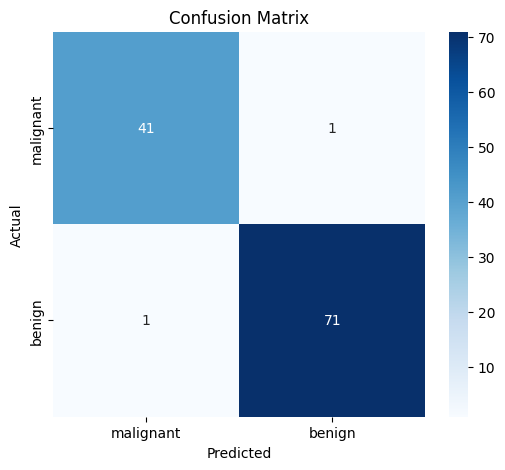

In [ ]:
#6. Create a confusion matrix visualization.
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Part B — Clustering + evaluation (5 marks)

Q4. KMeans on Iris + SSE (5)

Use Iris dataset for clustering.

1. Load Iris (X, y), but do clustering using X only (ignore labels for training).
2. Scale X.
3. Run KMeans with K=3.
4. Print:

* number of clusters found
* SSE score

5. Make a 2D scatter plot using any two features (e.g., feature 0 vs feature 2) colored by cluster labels.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load dataset
iris = load_iris()
X = iris.data  # ignore y

In [ ]:
# 2. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# 3. KMeans with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [ ]:
# 4. Outputs
print("Number of clusters found:", kmeans.n_clusters)
print("SSE (Inertia):", kmeans.inertia_)

Number of clusters found: 3
SSE (Inertia): 139.82049635974974


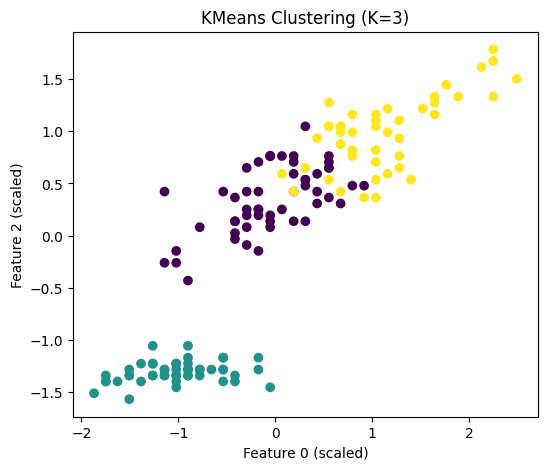

In [ ]:
# 5. Scatter plot (feature 0 vs feature 2)
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 2],
            c=kmeans.labels_, cmap='viridis')

plt.xlabel("Feature 0 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.title("KMeans Clustering (K=3)")
plt.show()